# 1 — The model and its equilibrium properties

The thesis asks whether the universal data of a conformal field theory — the central charge and
the boundary operator content — can be read from the real-time dynamics of a quantum chain that
is *not* integrable. The testbed is an ANNNI-type chain: the transverse-field Ising model with a
next-nearest-neighbour coupling of strength $p$,

$$H = -\sum_i\left[\sigma^z_i\sigma^z_{i+1} + \lambda\,\sigma^x_i
+ p\left(\sigma^z_i\sigma^z_{i+2} + \lambda\,\sigma^x_i\sigma^x_{i+1}\right)\right],$$

self-dual for every $p$, critical at $\lambda = 1$, genuinely interacting for any $p > 0$.
One convention to keep in mind throughout: the field sits on $\sigma^x$ and the order parameter
on $\sigma^z$ (the library's built-in Ising model has it the other way around).

This is the first of six notebooks that walk through the whole project:

1. **this one** — the model, why its dynamics needs dedicated machinery, and the two equilibrium
   facts everything else leans on (universality class, sound velocity);
2. the method (exponential MPO, the corrected transfer-matrix column, the Ising benchmark);
3. the temporal entropies and the wall;
4. the spectral route to the central charge;
5. the boundary operator spectrum;
6. the numerical controls, one by one.

Everything heavy is cached under `data/`; the cells load, fit and plot. The thesis figures are
produced by their owning scripts in `scripts/figures/` — the notebooks `include` those scripts
and call their `make_*()` functions, so what you see here is exactly what the PDF shows.

In [1]:
# load the library: model Hamiltonians, the temporal-MPO construction, the block power
# method, the entropy routines, and the plotting theme
include("../src/thesislib.jl")
using JLD2, Printf, Statistics
thesis_plot_theme!()

## The entanglement barrier, seen directly

Before any transverse machinery: what happens if we just evolve the quenched state
$|X+\rangle^{\otimes N}$ the standard way? The observable of the thesis is the Loschmidt
amplitude $L(T) = \langle\psi_0|e^{-iHT}|\psi_0\rangle$, and its rate
$\ell(T) = -\log|L|/N$ is perfectly well behaved. The *state*, however, is not: TDVP has to
grow the bond dimension to keep $|\psi(t)\rangle$ faithful, and the growth is relentless. The
run below (cached; $p=0.1$, $N=40$, $\delta t = 0.05$) tracks both.

[ Info: All target T values already cached.


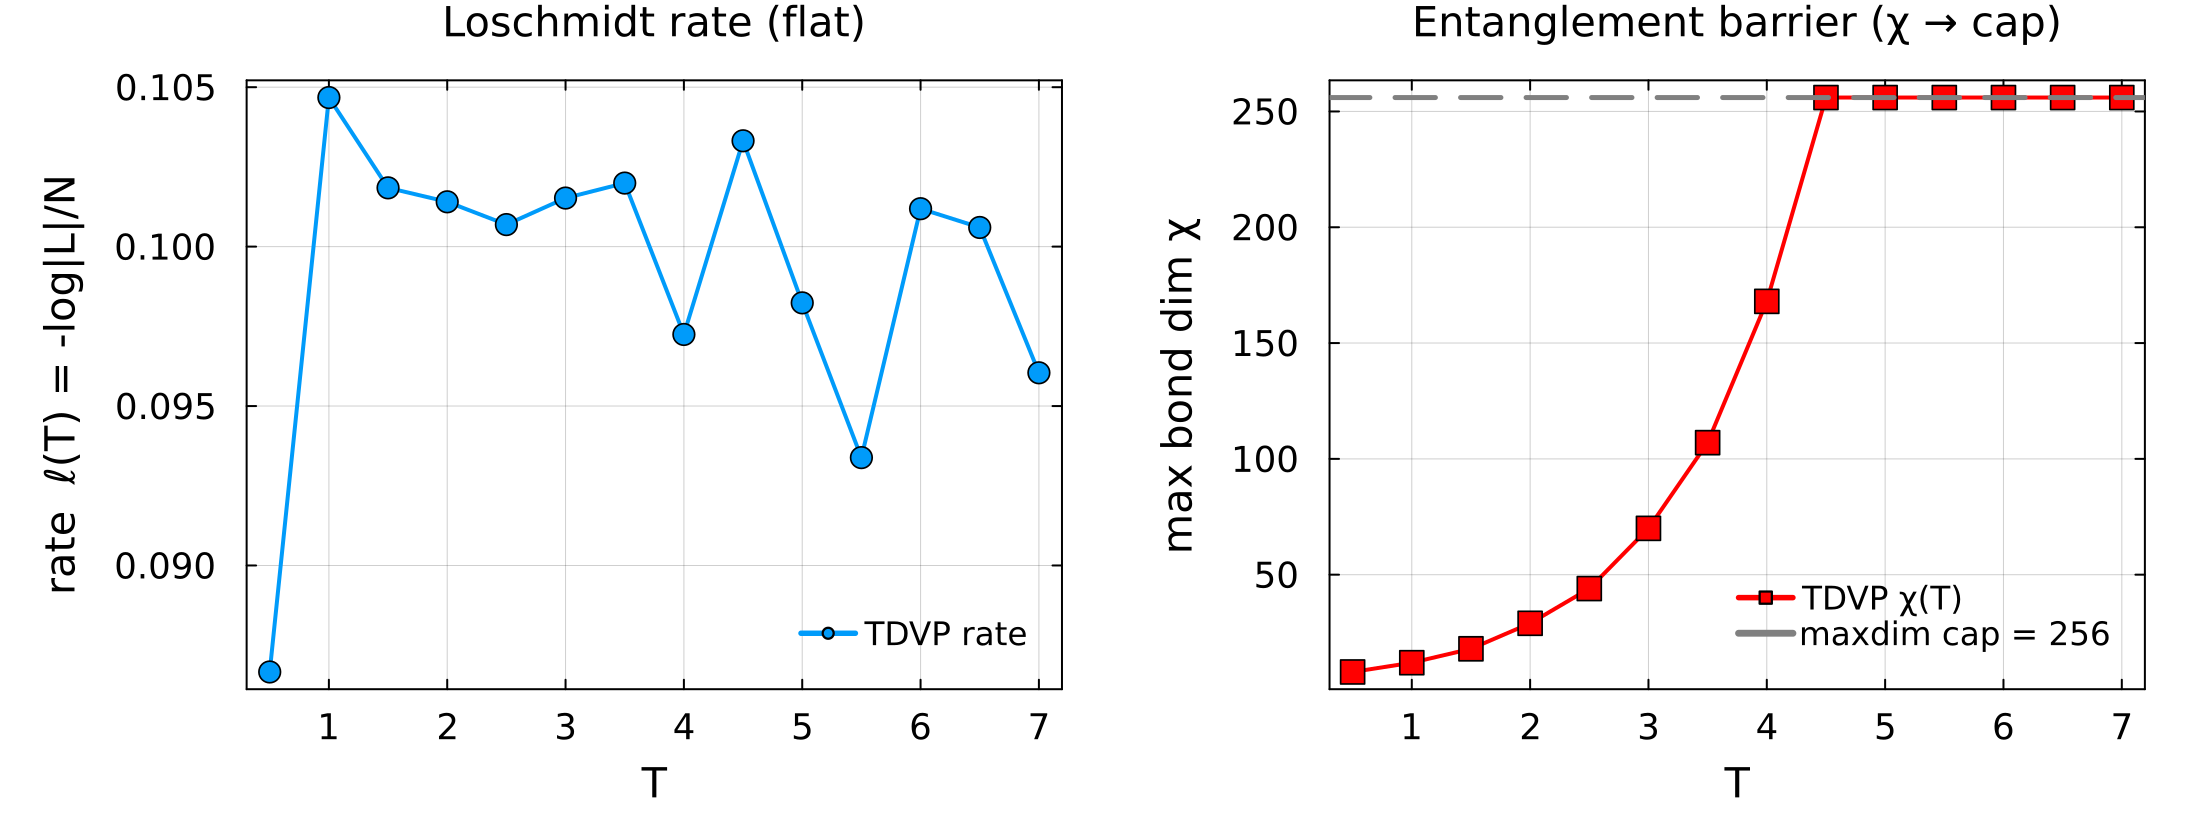

In [2]:
# TDVP Loschmidt run — loads from data/local/tdvp_loschmidt_p0.1_N40.jld2, computes only
# if a time is missing from the cache
tdvp = tdvp_loschmidt_amplitude(40, collect(0.5:0.5:7.0); p=0.1, lambda=1.0, dt=0.05)
Ts   = sort(collect(keys(tdvp)))
rate = [tdvp[T].rate   for T in Ts]
chi  = [tdvp[T].maxchi for T in Ts]

pr = plot(Ts, rate; xlabel="T", ylabel="rate  ℓ(T) = -log|L|/N", lw=2, marker=:circle,
          label="TDVP rate", title="Loschmidt rate (flat)")
pc = plot(Ts, chi;  xlabel="T", ylabel="max bond dim χ", lw=2, marker=:square, color=:red,
          label="TDVP χ(T)", title="Entanglement barrier (χ → cap)")
hline!(pc, [256]; ls=:dash, color=:gray, label="maxdim cap = 256")
plot(pr, pc; layout=(1, 2), size=(1100, 420), margin=5Plots.mm)

The rate is smooth and featureless — the *answer* is easy. But $\chi$ climbs roughly
exponentially and slams into the $\chi = 256$ cap around $T \approx 4.5$: past that point the
state is silently truncated and the simulation is no longer faithful. This is the entanglement
barrier, and it is the reason the thesis contracts the space–time network **sideways** instead:
transverse contraction trades the exploding *spatial* entanglement for the *temporal*
entanglement, which at a critical quench grows only logarithmically. That machinery is
notebook 2; the rest of this notebook pins down the equilibrium facts it will need.

## Is the model critical — and in which universality class?

The cleanest place to answer is the ground state. We compute it with DMRG and read the central
charge from the finite-size scaling of the half-chain entanglement entropy,
$S(L/2) = \tfrac{c}{6}\ln L + k$ for open chains, with the known subleading correction
$\propto L^{-1/n}$ for the Rényi-$n$ estimator included in the fit. First the one-glance
answer across the coupling:

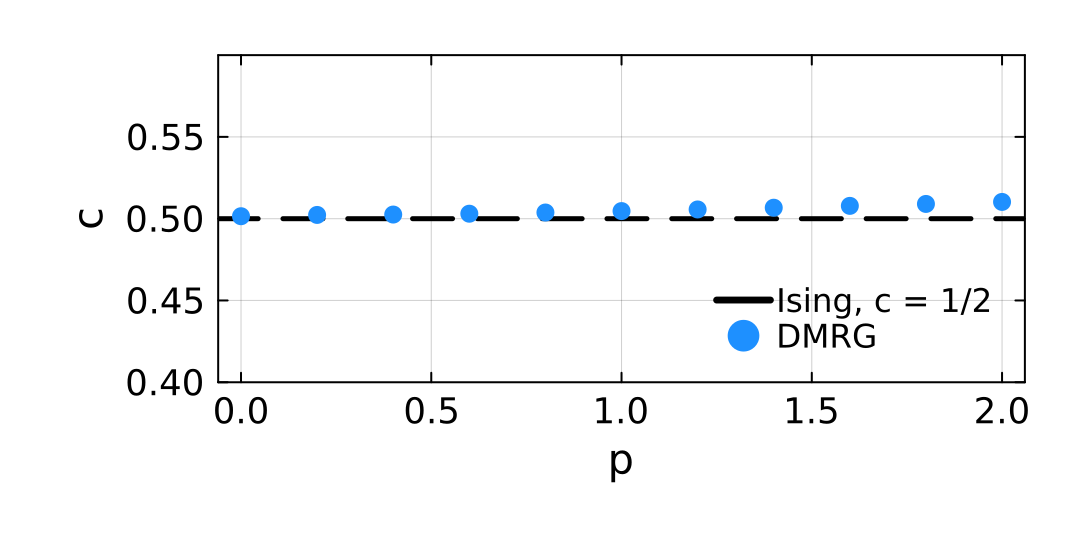

In [3]:
# equilibrium c(p) from the cached DMRG sweep: it stays on the Ising value
cvsp = load("../data/local/nb4_cvsp.jld2")
pl = plot(xlabel="p", ylabel="c", legend=:bottomright, ylims=(0.4, 0.6),
          size=thesis_size(0.7; aspect=0.5))
hline!(pl, [0.5], color=:black, ls=:dash, label="Ising, c = 1/2")
scatter!(pl, cvsp["p"], cvsp["c"], color=:dodgerblue, ms=5, msw=0, label="DMRG")
pl

Flat on $c = 1/2$. The careful version of the same statement is the thesis figure
`cft_L`: the scaling at two couplings with two estimators, and — panel (b) — the subleading
correction isolated, to show the fit is actually describing the data and not absorbing junk:

p=0.1  n=1 :  c = 0.5001   A = -0.154
p=0.5  n=1 :  c = 0.4997   A = -0.202


p=0.1  n=2 :  c = 0.5081   A = -0.178
p=0.5  n=2 :  c = 0.5048   A = -0.195


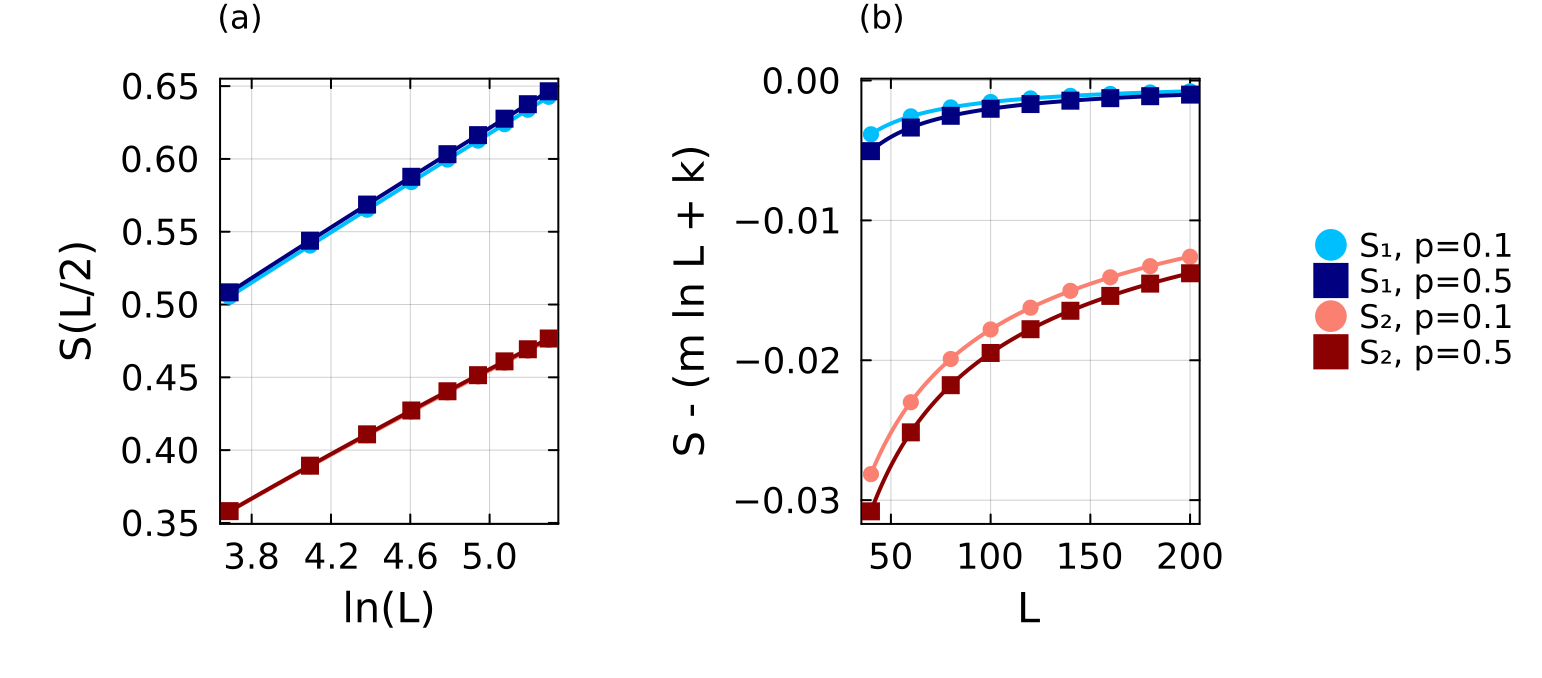

In [4]:
include("../scripts/figures/fig_cft_L.jl")
make_cft_L()

A complementary check uses one long chain ($N = 400$) and every cut at once: against the
chord variable $W(l, L) = \ln\left[\tfrac{2L}{\pi}\sin\tfrac{\pi l}{L}\right]$ the
conformal profile is a straight line of slope $c/6$. Eight couplings, eight straight lines,
eight fitted slopes — all $c \approx 0.502$, out to $p = 1.5$:

p=0.00 : c = 0.5020
p=0.10 : c = 0.5018


p=0.20 : c = 0.5018
p=0.30 : c = 0.5019
p=0.40 : c = 0.5020
p=0.50 : c = 0.5021
p=1.00 : c = 0.5036
p=1.50 : c = 0.5055
spread across p: 0.0449 at the first cut, 0.0204 at the central cut


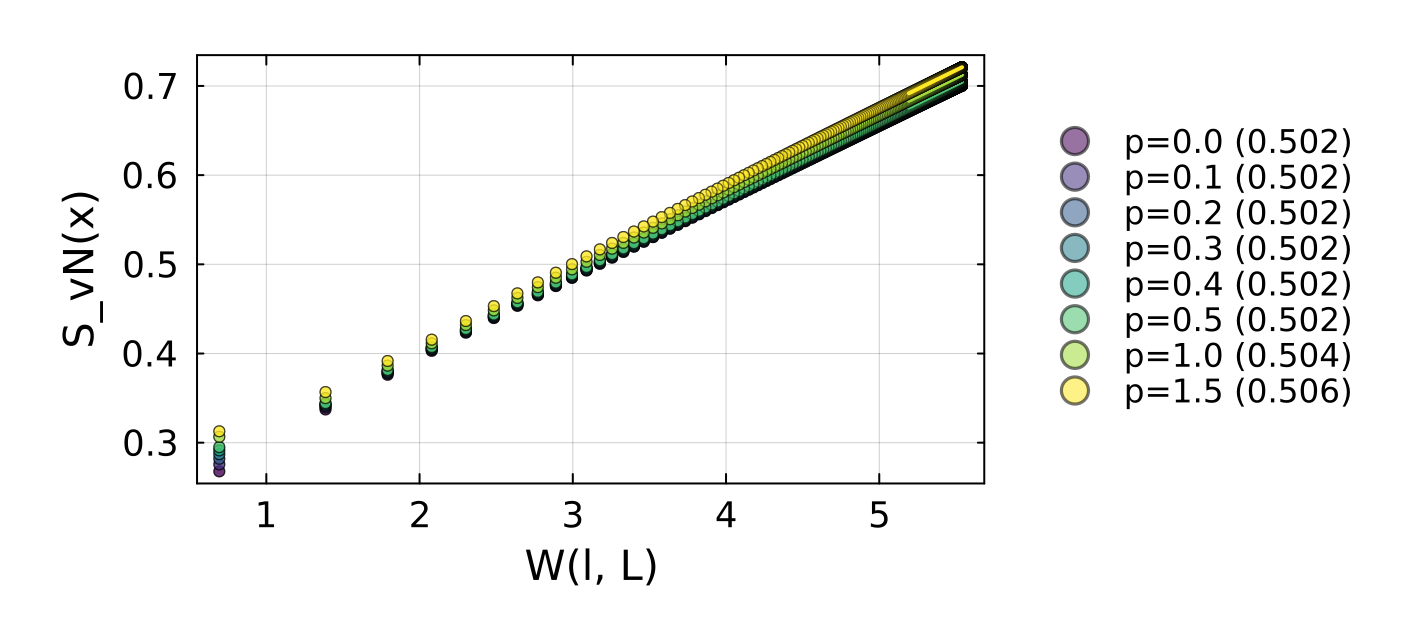

In [5]:
include("../scripts/figures/fig_chord_equilibrium.jl")
make_chord_equilibrium()

## The sound velocity

Everything dynamical later returns *phases*, and converting a phase gap into a scaling
dimension needs the non-universal sound velocity $v(p)$. We measure it on periodic rings by
exact diagonalisation, $v = N\,(E_1(k_{\min}) - E_0)/2\pi|k_{\min}|$, at
$N = 10, \dots, 18$, and extrapolate in $1/N^2$. The $p = 0$ control has to land on the exact
$v = 2$ — it lands within $2\times10^{-5}$.

v_inf(p): v(0.0)=2.000  v(0.1)=2.670  v(0.2)=3.326  v(0.3)=3.967  v(0.4)=4.596  v(0.5)=5.212  v(1.0)=8.126  v(1.5)=10.799


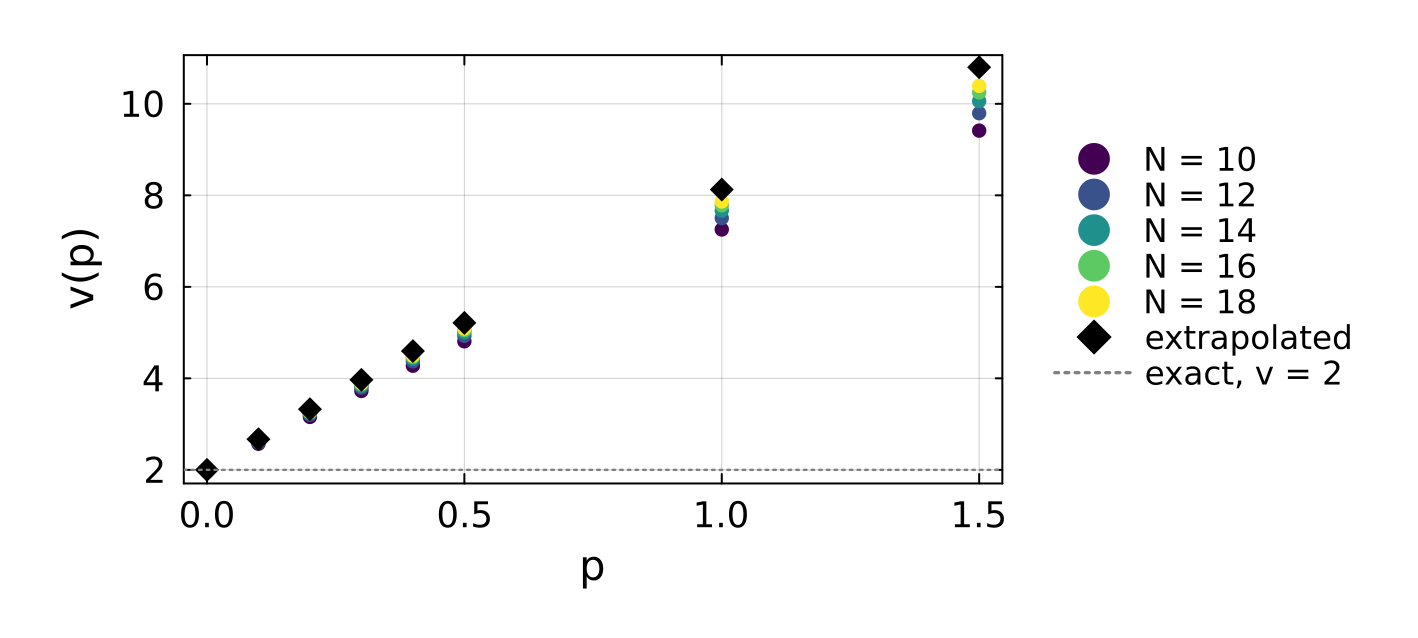

In [6]:
include("../scripts/figures/fig_velocity_vs_p.jl")
make_velocity_vs_p()

p=0: intercept 1.99994, exact 2, error 6.0e-05


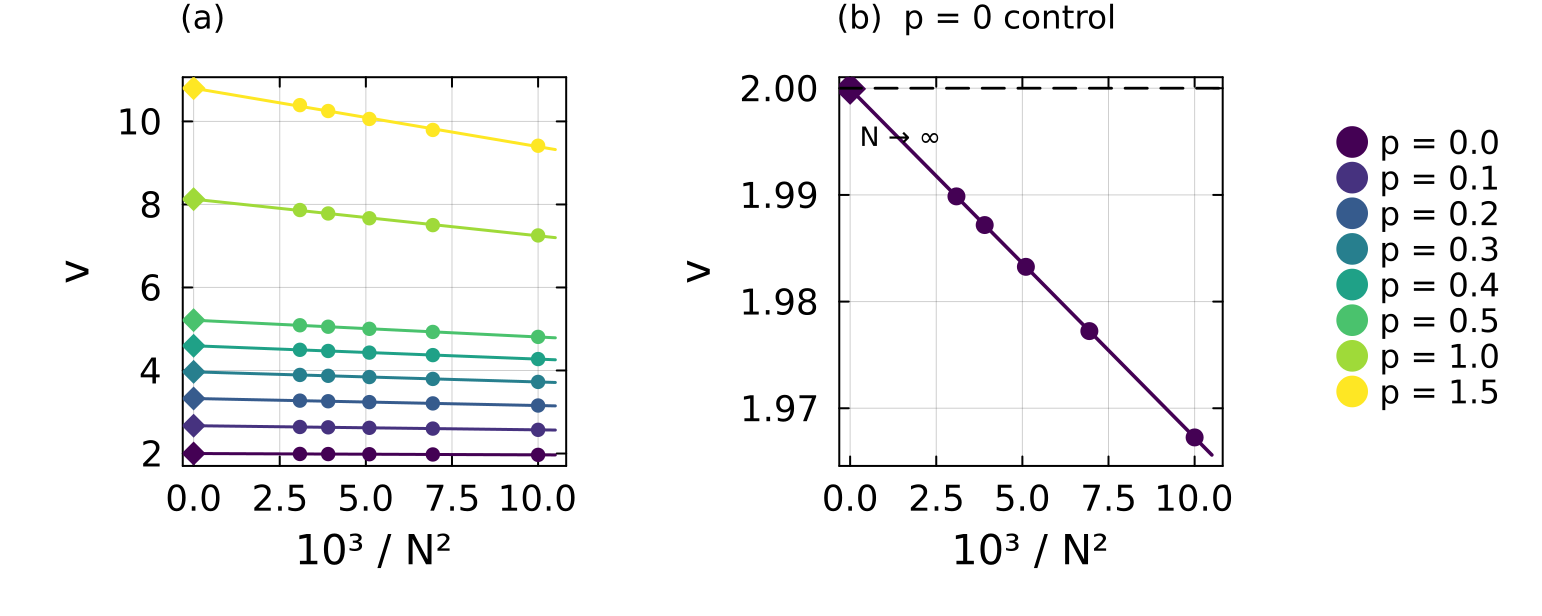

In [7]:
include("../scripts/figures/fig_velocity_extrap.jl")
make_velocity_extrap()

## Takeaways

- Direct evolution is fine for the echo but hits the entanglement barrier by $T \approx 4.5$
  already at $N = 40$ — the motivation for everything that follows.
- The model sits in the **Ising class across the whole range**: equilibrium $c = 0.502$ at
  every coupling up to $p = 1.5$, by two independent estimators.
- The extrapolated velocities $v_\infty(p)$ — 2.000, 2.670, 3.326, 3.967, 4.596, 5.212 at
  $p = 0, \dots, 0.5$ — live in `data/local/alcaraz_velocity.jld2` and enter every fit in
  notebooks 4 and 5.